Import basic Python modules and use Jupyter magic syntax for inline `matplotlib` plots

In [14]:
import sys
from pathlib import Path

# Add the parent directory (nnz2h) to sys.path
parent_dir = Path.cwd().parent
if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

import pygrad

import math
import numpy as np
import matplotlib.pyplot as plt
# jupyter magic:
%matplotlib inline

Define a function $f(x)$ to use when exploring the derivative.

In [15]:
def f(x):
  return 3*x**2-4*x+5

Example function usage: $f(3) = 20$ because $3x^2-4x+5$ evaluated at $x=3$ gives: $3 \cdot 3^2-4 \cdot 3+5 = 3 \cdot 9-12+5 = 27-7 = 20$.

In [16]:
f(3.0)

20.0

Plot the function $f(x)$ for $x$ ranging from $-5$ to $5$ at steps of $0.25$.

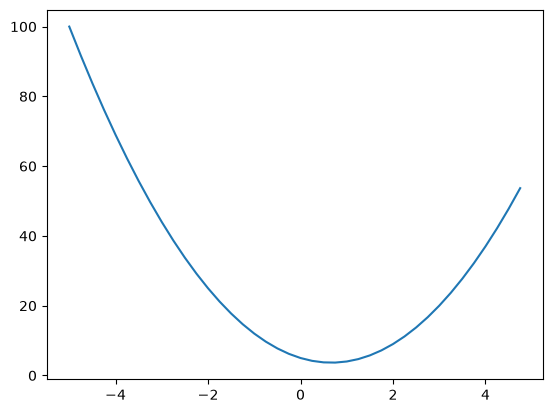

In [17]:
xs = np.arange(-5.0,5.0,0.25)
ys = f(xs)
plt.plot(xs,ys)

What is the derivative of this function? Symbolically, we know that $\frac{d}{dx}f(x) = \frac{d}{dx}\left(3x^2-4x+5\right) = 6x-4$. Previously, we evaluated $f(3) = 20$. Using the symbolically-derivated derivated, $f'(3) = 6 \cdot 3-4 = 18-4 = 14$.

However, the plot above evaluates the function numerically and consists of discrete pairs of input and output values. To generalize our evaluation of the derivative, we need to use the definition of the derivative: $\lim_{h\to 0}\frac{f(a+h)-f(a)}{h}$. Choosing a sufficiently small $h$ (but not too small to cause instability in digital representation of numbers) approximates the derivative.

In [18]:
h = 0.01
x = 3.0
# numerically approximate the derivative using the limit definition
(f(x+h)-f(x))/h

14.029999999999632

As $h$ gets smaller, the numerical approximation of the derivative approaches the symbolically-derivated value.

In [19]:
# numerically calculate the derivative of the given function and input for a list of h values
# _n_umerical _d_erivative_s_
def nds(f, x, hs):
  return [(f(x+h)-f(x))/h for h in hs]

nds(f,3.0,[0.1,0.01,0.001])

[14.300000000000068, 14.029999999999632, 14.00300000000243]

Let's perform the same evaluation at $x=-3$. The expected result is $f'(-3) = 6 \cdot -3 - 4 = -22$.

In [20]:
nds(f,-3.0,[0.1,0.01,0.001,0.0001,0.00001])

[-21.700000000000017,
 -21.9699999999996,
 -21.996999999998934,
 -21.999700000066014,
 -21.999970000052823]

Finally, let's confirm the zero-derivative case. Solving for $x$: $0 = 6x-4$ gives $x=2/3$. Using the numerical approximation, as $h$ approaches $0$ we obtain a derivative of $0$.

In [21]:
nds(f,2.0/3.0,[0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001])

[0.29999999999999805,
 0.02999999999997449,
 0.0029999999995311555,
 0.0002999999981767587,
 3.0000002482211127e-05,
 2.999378523327323e-06,
 2.9753977059954195e-07,
 0.0]

Next, let's consider a function $d$ of three independent variables $a$, $b$, and $c$. To start, we evaluate $d(a=2,b=-3,c=10)$.

In [22]:
a = 2.0
b = -3.0
c = 10.0
d = a*b+c
print(d)

4.0


Define a new function that accepts three arguments: the function perturbed by $h$, the unperturbed function, and the value of $h$. Start by numerically determining the derivative of $d$ with respect to $a$. Analytically, $\frac{d}{da}d=-3$ when $b=-3$ and $c=10$ (check for yourself). We see that the numerical method agrees and gives $-3$.

In [23]:
# redefine a, b, and c to avoid bugs
a = 2.0
b = -3.0
c = 10.0

# _n_umerical _d_erivative
def nd(fph, f, h):
  return (fph-f)/h

# sweep h values
nds = []
for hi in [0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001]:
  dloc = a*b+c
  daph = (a+hi)*b+c
  nds.append(nd(daph,dloc,hi))

# display the results
nds

[-3.000000000000007,
 -2.999999999999936,
 -3.0000000000001137,
 -3.000000000010772,
 -3.000000000064062,
 -3.000000000419334,
 -2.9999999995311555,
 -2.999999981767587]

Perform the same analysis relative to $b$. Analytically, $\frac{d}{db}d = 2$ when $a=2$ and $c=10$. Check that the numerical derivative agrees.

In [24]:
# redefine a, b, and c to avoid bugs
a = 2.0
b = -3.0
c = 10.0

# sweep h values
nds = []
for hi in [0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001]:
  dloc = a*b+c
  dbph = a*(b+hi)+c
  nds.append(nd(dbph,dloc,hi))

# display the results
nds

[2.0000000000000018,
 1.9999999999999574,
 1.9999999999997797,
 2.0000000000042206,
 2.0000000000131024,
 2.000000000279556,
 1.9999999967268423,
 1.999999987845058]

Finally, differentiate relative to $c$. Analytically, $\frac{d}{dc}=1$. Check the numerical derivative.

In [25]:
# redefine a, b, and c to avoid bugs
a = 2.0
b = -3.0
c = 10.0

# sweep h values
nds = []
for hi in [0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001]:
  dloc = a*b+c
  dcph = a*b+c+hi
  nds.append(nd(dcph,dloc,hi))

# display the results
nds

[0.9999999999999964,
 0.9999999999999787,
 1.000000000000334,
 0.9999999999976694,
 0.9999999999621422,
 1.000000000139778,
 1.0000000028043132,
 0.999999993922529]

Tracking these derivatives (or **gradients**) manually is tedious. Let's import the `Scalar` class from `pygrad`.

In [26]:
from pygrad import Scalar

Let's perform some tests. Note that the Scalar class tracks not only the value of the scalar, but also the gradient ("grad") of the scalar. Because we have not performed any operations yet, the gradient is zero.

In [27]:
a = Scalar(2.0)
a

Scalar(value=2.000000,grad=0.000000)

Scalar objects support many operations, including multiplication. Let's test multiplication.

In [28]:
a = Scalar(2.0)
b = Scalar(-3.0)
a*b

Scalar(value=-6.000000,grad=0.000000)

Scalar objects track the values that produce them. Let's reproduce the calculation for $d$ and inspect the resulting object. We expect $d$ to be produced from $-6$ ($a$ times $b$) and $10$ ($c$) using an addition operation.

In [29]:
a = Scalar(2.0)
b = Scalar(-3.0)
c = Scalar(10.0)
d = a*b+c
print(d)
print('Sources:',d._srcs)
print('Op:',d._op)

Scalar(value=4.000000,grad=0.000000)
Sources: {Scalar(value=10.000000,grad=0.000000), Scalar(value=-6.000000,grad=0.000000)}
Op: +


Visualizing these operation graphs is useful. Import the `pygrad` visualization tools.

In [30]:
import pygrad.viz as pgv

Next, visualize the computation graph that produced $d$.

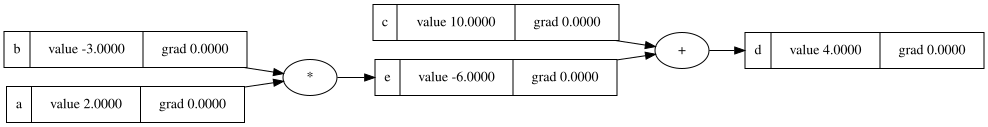

In [31]:
a = Scalar(2.0, _id='a')
b = Scalar(-3.0, _id='b')
c = Scalar(10.0, _id='c')
e = a*b; e._id = 'e'
d = e+c; d._id = 'd'
pgv.draw_graph(d)

Before addressing the gradients, let's augment this expression with an additional multiplier $f$ and a final value $L$.

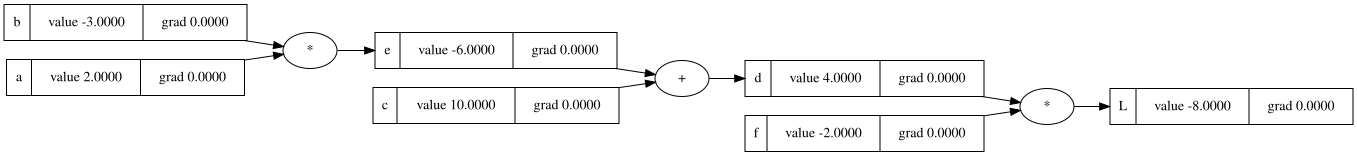

In [32]:
a = Scalar(2.0, _id='a')
b = Scalar(-3.0, _id='b')
c = Scalar(10.0, _id='c')
e = a*b; e._id = 'e'
d = e+c; d._id = 'd'
f = Scalar(-2.0, _id='f')
L = d*f; L._id = 'L'
pgv.draw_graph(L)

In the visual graph representation of the calculation, the gradients are all zero. Let's manually determine what some of these gradients should be. First, what is the gradient of $L$? Using the definition of the derivative, $f'(L)=\frac{(L+h)-L}{h}=1$. So, the gradient of $L$ with respect to itself is $1$. Set the gradient of the `Scalar` object $L$ to $1.0$.

In [33]:
L.grad = 1.0
L.grad

1.0

What is the derivative of $L$ with respect to $d$, i.e., what is $\frac{d}{dd}L$? Analytically, we can write $L=d \cdot f$. As a result, $\frac{d}{dd}L=\frac{d}{dd} d f = f$. In this case, $f=-2$ so $\frac{d}{dd}L=-2$. Let's confirm this result numerically. We perform the check inside of a function to avoid polluting the global namespace.

In [34]:
def check_dL_dd():
  # calculate the base value of L
  def calc_base_L():
    a = Scalar(2.0, _id='a')
    b = Scalar(-3.0, _id='b')
    c = Scalar(10.0, _id='c')
    e = a*b; e._id = 'e'
    d = e+c; d._id = 'd'
    f = Scalar(-2.0, _id='f')
    L = d*f; L._id = 'L'
    return L.value
  L_base = calc_base_L()
  # calculate perturbed values of L for a range of h values
  def calc_pert_L(hs):
    Ls = []
    for hi in hs:
      a = Scalar(2.0, _id='a')
      b = Scalar(-3.0, _id='b')
      c = Scalar(10.0, _id='c')
      e = a*b; e._id = 'e'
      d = e+c; d._id = 'd'; d.value+=hi
      f = Scalar(-2.0, _id='f')
      L = d*f; L._id = 'L'
      Ls.append([hi,L.value])
    return Ls
  L_perts = calc_pert_L([0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001])
  # calculate the _num_erical _d_erivative_s_
  num_ds = []
  for L_pert in L_perts:
    num_ds.append(nd(L_pert[1],L_base,L_pert[0]))
  # print numerical derivatives
  print(num_ds)

# call the function
check_dL_dd()

[-1.999999999999993, -1.9999999999999574, -2.000000000000668, -1.9999999999953388, -1.9999999999242843, -2.000000000279556, -2.0000000056086265, -1.999999987845058]


By symmetry, $\frac{d}{df}L=d$. In this case, $\frac{d}{df}L=4$. Let's confirm numerically.

In [35]:
def check_dL_df():
  # calculate the base value of L
  def calc_base_L():
    a = Scalar(2.0, _id='a')
    b = Scalar(-3.0, _id='b')
    c = Scalar(10.0, _id='c')
    e = a*b; e._id = 'e'
    d = e+c; d._id = 'd'
    f = Scalar(-2.0, _id='f')
    L = d*f; L._id = 'L'
    return L.value
  L_base = calc_base_L()
  # calculate perturbed values of L for a range of h values
  def calc_pert_L(hs):
    Ls = []
    for hi in hs:
      a = Scalar(2.0, _id='a')
      b = Scalar(-3.0, _id='b')
      c = Scalar(10.0, _id='c')
      e = a*b; e._id = 'e'
      d = e+c; d._id = 'd'
      f = Scalar(-2.0+hi, _id='f')
      L = d*f; L._id = 'L'
      Ls.append([hi,L.value])
    return Ls
  L_perts = calc_pert_L([0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001])
  # calculate the _num_erical _d_erivative_s_
  num_ds = []
  for L_pert in L_perts:
    num_ds.append(nd(L_pert[1],L_base,L_pert[0]))
  # print numerical derivatives
  print(num_ds)

# call the function
check_dL_df()

[4.0000000000000036, 4.0000000000000036, 3.9999999999995595, 3.9999999999995595, 4.000000000026205, 3.9999999996709334, 4.000000002335469, 3.999999975690116]


Let's fill in the gradients that we have already determined and visualize the function graph again.

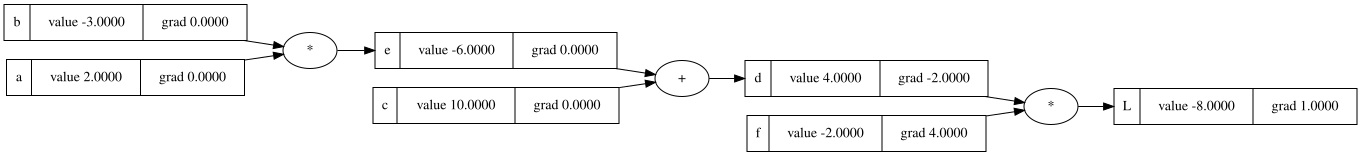

In [36]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
pgv.draw_graph(L)

Next, we determine the gradient of $c$ with respect to $L$ or, more specifically, we determine $\frac{d}{dc}L$.

First, determine $\frac{d}{dc}d$. Since $d = c+e$, then $\frac{d}{dc}d = 1$ analytically. This result can also be derived from the definition of the derivative: $\frac{f(x+h)-f(x)}{h} = \frac{(c+h)+e-(c+e)}{h} = \frac{c+h+e-c-e}{h}=\frac{h}{h}=1$.

Given this local derivative $\frac{dd}{dc}$ and the previously determined derivative $\frac{dL}{dd}$, what is $\frac{dL}{dc}$? Use the chain rule: $\frac{dL}{dd}=\frac{dd}{dc}\frac{dL}{dd}$. In this case, $\frac{d}{dc}L= 1 \cdot -2 = -2$.

Applying the same logic to $e$, it is the case that $\frac{dL}{de} = -2$.

Let's confirm numerically.

In [37]:
def check_dL_de():
  # calculate the base value of L
  def calc_base_L():
    a = Scalar(2.0, _id='a')
    b = Scalar(-3.0, _id='b')
    c = Scalar(10.0, _id='c')
    e = a*b; e._id = 'e'
    d = e+c; d._id = 'd'
    f = Scalar(-2.0, _id='f')
    L = d*f; L._id = 'L'
    return L.value
  L_base = calc_base_L()
  # calculate perturbed values of L for a range of h values
  def calc_pert_L(hs):
    Ls = []
    for hi in hs:
      a = Scalar(2.0, _id='a')
      b = Scalar(-3.0, _id='b')
      c = Scalar(10.0, _id='c')
      e = a*b; e._id = 'e'; e+=hi
      d = e+c; d._id = 'd'
      f = Scalar(-2.0, _id='f')
      L = d*f; L._id = 'L'
      Ls.append([hi,L.value])
    return Ls
  L_perts = calc_pert_L([0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001])
  # calculate the _num_erical _d_erivative_s_
  num_ds = []
  for L_pert in L_perts:
    num_ds.append(nd(L_pert[1],L_base,L_pert[0]))
  # print numerical derivatives
  print(num_ds)

# call the function
check_dL_de()

[-1.999999999999993, -1.9999999999999574, -2.000000000000668, -1.9999999999953388, -1.9999999999242843, -2.000000000279556, -2.0000000056086265, -1.999999987845058]


Let's fill in the gradients that we have already determined and visualize the function graph again.

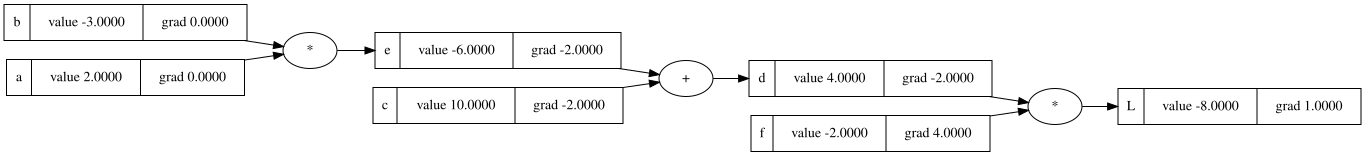

In [38]:
e.grad = -2.0
c.grad = -2.0
pgv.draw_graph(L)

Apply the chain rule again to find $\frac{dL}{db}$, i.e., $\frac{de}{db}\frac{dL}{de}$. Recall that $\frac{dL}{de}=-2$.

First, determine $\frac{de}{db}$. Since $e = a*b$, then $\frac{d}{db}e=\frac{d}{db}a*b=a$. Here, $a=2$.

Now $\frac{de}{db}\frac{dL}{de}=2 \cdot -2=-4$.

Verify numerically:

In [39]:
def check_dL_db():
  # calculate the base value of L
  def calc_base_L():
    a = Scalar(2.0, _id='a')
    b = Scalar(-3.0, _id='b')
    c = Scalar(10.0, _id='c')
    e = a*b; e._id = 'e'
    d = e+c; d._id = 'd'
    f = Scalar(-2.0, _id='f')
    L = d*f; L._id = 'L'
    return L.value
  L_base = calc_base_L()
  # calculate perturbed values of L for a range of h values
  def calc_pert_L(hs):
    Ls = []
    for hi in hs:
      a = Scalar(2.0, _id='a')
      b = Scalar(-3.0+hi, _id='b')
      c = Scalar(10.0, _id='c')
      e = a*b; e._id = 'e'
      d = e+c; d._id = 'd'
      f = Scalar(-2.0, _id='f')
      L = d*f; L._id = 'L'
      Ls.append([hi,L.value])
    return Ls
  L_perts = calc_pert_L([0.1,0.01,0.001,0.0001,0.00001,0.000001,0.0000001,0.00000001])
  # calculate the _num_erical _d_erivative_s_
  num_ds = []
  for L_pert in L_perts:
    num_ds.append(nd(L_pert[1],L_base,L_pert[0]))
  # print numerical derivatives
  print(num_ds)

# call the function
check_dL_db()

[-4.0000000000000036, -3.9999999999999147, -3.9999999999995595, -4.000000000008441, -4.000000000026205, -4.000000000559112, -3.9999999934536845, -3.999999975690116]


Using the same process, $\frac{dL}{da}=6$. Let's fill in the final gradients and visualize the function graph again.

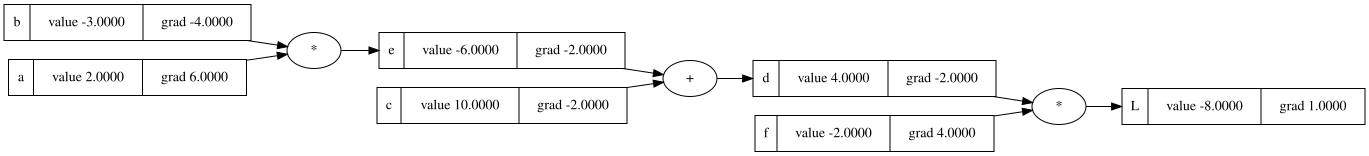

In [40]:
b.grad = -4.0
a.grad = 6.0
pgv.draw_graph(L)

Now that we have hand-calculated the gradient of every term with respect to the output $L$, let's use the results to decrease $L$ by adjusting one of the inputs. Here, the inputs are the leaf nodes.

Since $\frac{dL}{da}=6$, perturbing $a$ in the positive direction increases $L$.

Since $\frac{dL}{db}=-4$, perturbing $b$ in the positive direction decreases $L$.

So, one way to ensure that a perturbation of an input decreases $L$ is to take the small perturbation (e.g., $0.01$) and multiply by the negative gradient. If the gradient is positive, the perturbation is negative (thus decreasing $L$ as with $a$), and if the gradient is negative, the perturbation is positive (thus decreasing $L$ as with $b$).

Let's perform such a perturbation for all leaf nodes inside a function to protect scope.

In [41]:
def pert_L():
  # set leaf node values and gradients
  a = Scalar(2.0, _id='a'); a.grad = 6.0
  b = Scalar(-3.0, _id='b'); b.grad = -3.0
  c = Scalar(10.0, _id='c'); c.grad = -2.0
  e = a*b; e._id = 'e'
  d = e+c; d._id = 'd'
  f = Scalar(-2.0, _id='f'); f.grad = 4.0
  L_base = d*f; L_base._id = 'L'; L_base.grad = 1.0
  # print unperturbed L
  print('Orig L:',L_base.value)
  # perturb leaf nodes to decrease L
  step = -0.01
  a.value += step*a.grad
  b.value += step*b.grad
  c.value += step*c.grad
  f.value += step*f.grad
  # recalculate L
  e = a*b; e._id = 'e'
  d = e+c; d._id = 'd'
  L_pert = d*f; L_pert._id = 'L'; L_pert.grad = 1.0
  # print perturbed L
  print('Pert L:',L_pert.value)

# call the function
pert_L()

Orig L: -8.0
Pert L: -8.686727999999999


Next, let's "back propagate" gradients through the function graph for a neuron. First, some background. The following image illustrates a biological neuron, which inspires the mathematical representation of neurons in artificial intelligence.

![Bio Neuron](./img/01-bio-neuron.png)

The mathematical representation of a neuron used in artificial intelligence takes several scalar inputs (i.e., a vector of inputs). Each input is multiplied by a corresponding weight particular to the neuron. These input-weight products are summed. In other words, there exists a weight vector particular to the neuron of equal length to the input vector, and the neuron calculates the dot product of the input vector and the weight vector. This dot product is then shifted by a bias term particular to the neuron. The result is passed through an activation function (usually nonlinear) and output to one or more subsequent neurons.

![MLP Neuron](./img/01-mlp-neuron.png)

An example of a nonlinear activation function is the hyperbolic tangent, i.e., $\tanh$. Let's visualize the tanh function. At inputs near 0, the output is similar to the input (both in the positive and negative direction). However, as the inputs become very positive or very negative, the output saturates at 1 (for positive inputs) or -1 (for negative inputs).

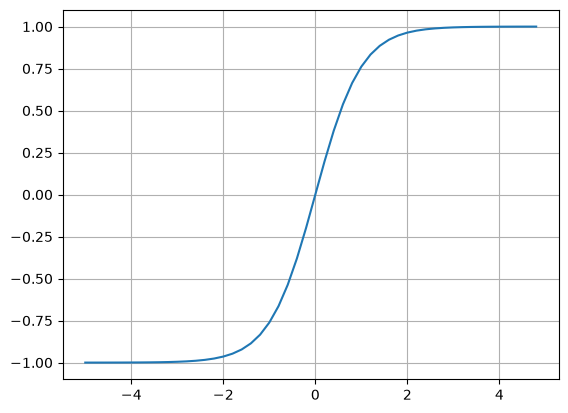

In [42]:
plt.plot(np.arange(-5,5,0.2),np.tanh(np.arange(-5,5,0.2))); plt.grid();

Using the `Scalar` class, let's implement the neuron function graph for an inputs size of just two, with two corresponding weights and a bias term. Then let's visualize the result.

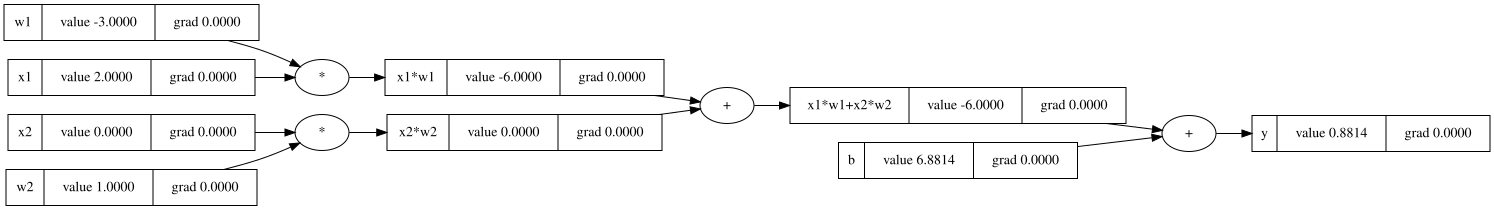

In [43]:
# inputs
x1 = Scalar(2.0, _id='x1')
x2 = Scalar(0.0, _id='x2')

# weights
w1 = Scalar(-3.0, _id='w1')
w2 = Scalar(1.0, _id='w2')

# bias
b = Scalar(6.8813735870195432, _id='b')

# dot product + bias term
x1w1 = x1*w1; x1w1._id = 'x1*w1'
x2w2 = x2*w2; x2w2._id = 'x2*w2'
x1w1x2w2 = x1w1+x2w2; x1w1x2w2._id = 'x1*w1+x2*w2'
y = x1w1x2w2+b; y._id = 'y'

# visualize
pgv.draw_graph(y)

This function graph for a neuron lacks an activation function. Let's use tanh as the activation function.

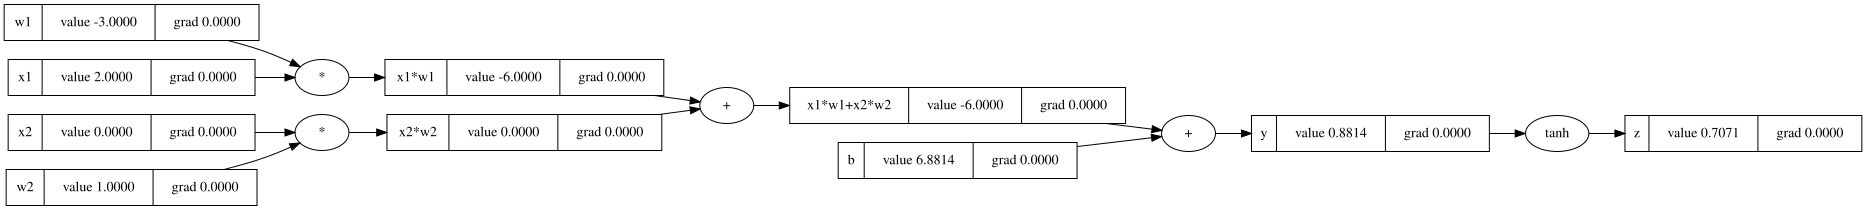

In [44]:
# activation function
z = Scalar.tanh(y); z._id = 'z'

# visualize
pgv.draw_graph(z)

Let's determine the gradients with respect to the output for each node. In an actual neural network, the weights are the only values that can be controlled and, therefore, are the only values for which the gradient must be calculated. However, for this exercise, we will determine all gradients.

To start, the derivative of $z$ with respect to itself is $1$. So, we set the gradient of $z$ to $1$.

Then, we determine the gradient of $z$ with respect to $y$, i.e., $\frac{d}{dy}z$. In other words, find $\frac{d}{dy}\tanh(y)$. There are several known expressions for this derivative, and a particularly convenient expression is $\frac{d}{dy}\tanh(y) = 1-\tanh^2(y)$ (because we already have a value for $\tanh(y) = z$). Thus, the gradient $\frac{dz}{dy} = 1-\tanh^2(y) = 1-z^2$. Numerically: $1-z^2 \approx 1-(0.7071)^2 = 0.5$.

The next two nodes are labeled `b` and `x1*w1+x2*w2`. The `y` node is the sum of these two nodes, which means that the gradient transfers directly to these nodes (recall the pattern from earlier). Therefore, these gradients with respect to $z$ are also $0.5$.

Node `x1*w1+x2*w2` is the sum of node `x1*w1` and `x2*w2`, which means that the gradients transfer directly again.

Let's set these gradients and view the graph representation.

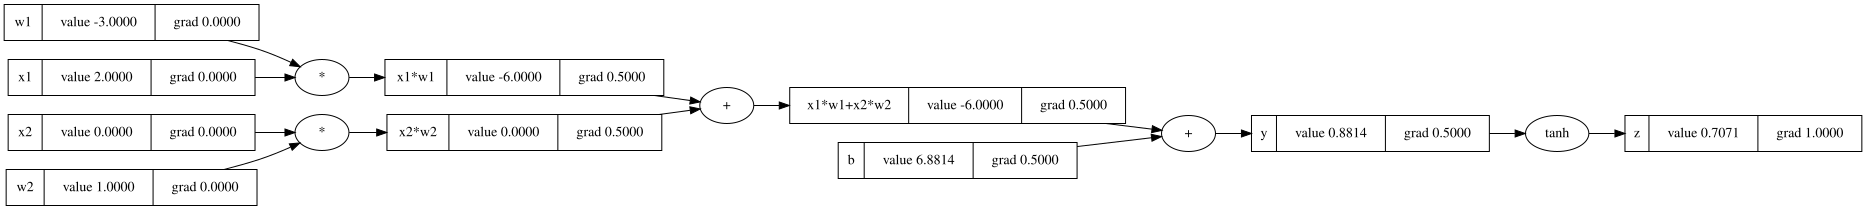

In [45]:
z.grad = 1.0
dzdy = 1.0-z.value**2.0
y.grad = dzdy
b.grad = dzdy
x1w1x2w2.grad = dzdy
x1w1.grad = dzdy
x2w2.grad = dzdy
pgv.draw_graph(z)

Recalling the pattern for back propagation through multiplication from earlier, the gradient is the value of the other input times the gradient of the output. So, for $x_1 w_1$, the gradient $\frac{dz}{dw_1}$ is $2 \times 0.5 = 1$, and the gradient $\frac{dz}{dx_1}$ is $-3 \times 0.5 = -1.5$.

For $x_2 w_2$, the gradient $\frac{dz}{dw_2}$ is $0 \times 0.5 = 0$, and the gradient $\frac{dz}{dx_2}$ is $1 \times 0.5 = 0.5$.

Let's set these gradients and view the graph representation.

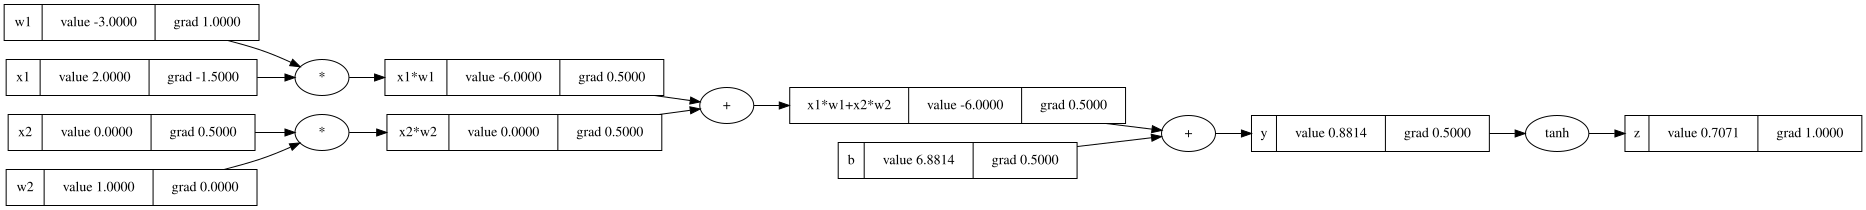

In [46]:
x2.grad = w2.value*x2w2.grad
w2.grad = x2.value*x2w2.grad
x1.grad = w1.value*x1w1.grad
w1.grad = x1.value*x1w1.grad
pgv.draw_graph(z)

The `Scalar` class of the `pygrad` package support automated back-propagation of gradients. Now that we understand how to manually generate the gradients, let's leverage the automatic gradient calculation tools. Let's reset all of the gradients to zero and visualize the graph to ensure that they have been cleared.

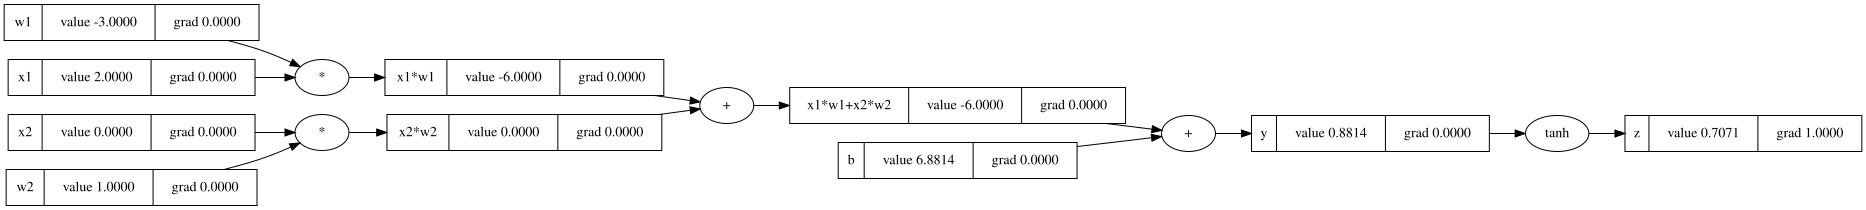

In [47]:
z.grad = 1.0
y.grad = 0.0
b.grad = 0.0
x1w1x2w2.grad = 0.0
x1w1.grad = 0.0
x2w2.grad = 0.0
x2.grad = 0.0
w2.grad = 0.0
x1.grad = 0.0
w1.grad = 0.0
pgv.draw_graph(z)

To automatically accumulated gradients, we call `acc_grads` on each node (in the correct order). Let's do half of them.

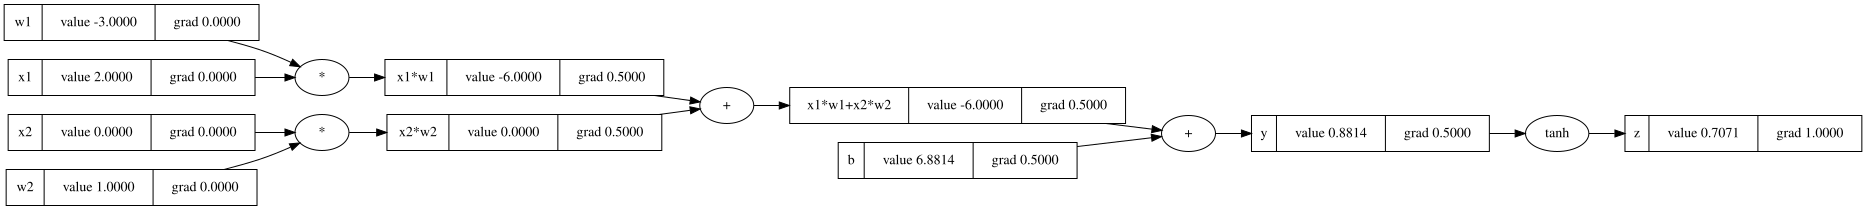

In [48]:
z._acc_grads()
y._acc_grads()
b._acc_grads()
x1w1x2w2._acc_grads()
pgv.draw_graph(z)

Accumulate the gradients for $x_2$ and $w_2$:

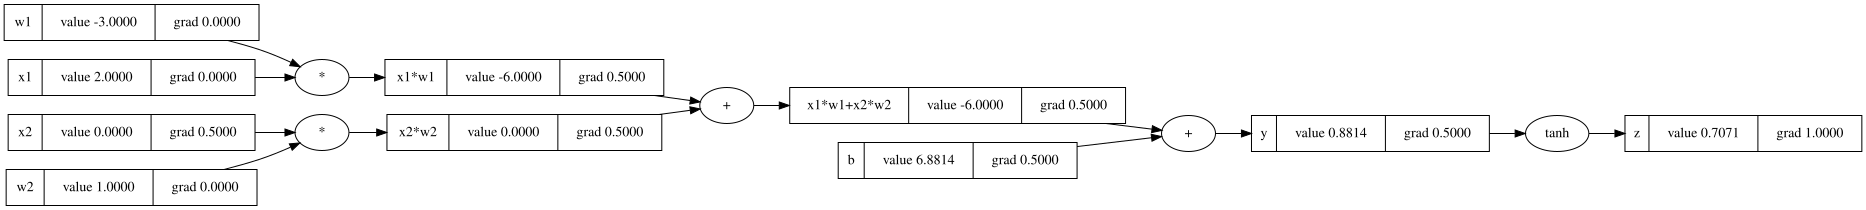

In [49]:
x2w2._acc_grads()
pgv.draw_graph(z)

Accumulate the gradients for $x_1$ and $w_1$:

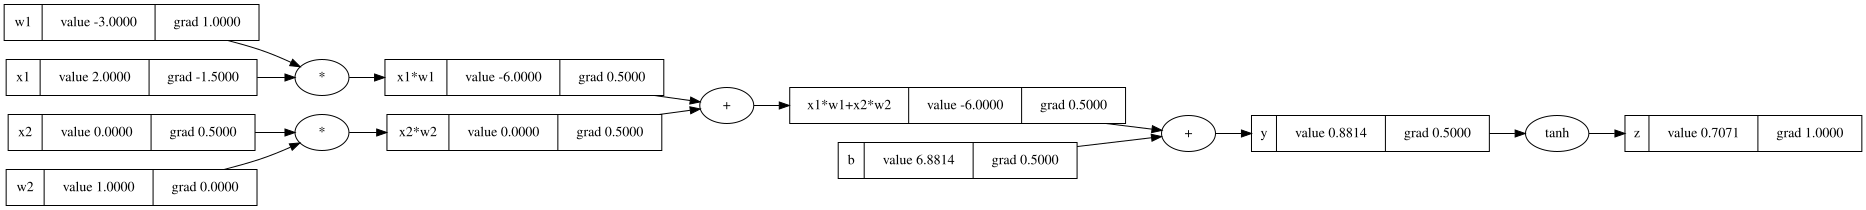

In [50]:
x1w1._acc_grads()
pgv.draw_graph(z)

This method is still inconvenient, because we need to call the gradient accumulation function for each node and be careful about the order in which the gradients accumulate. So, we clear all gradients.

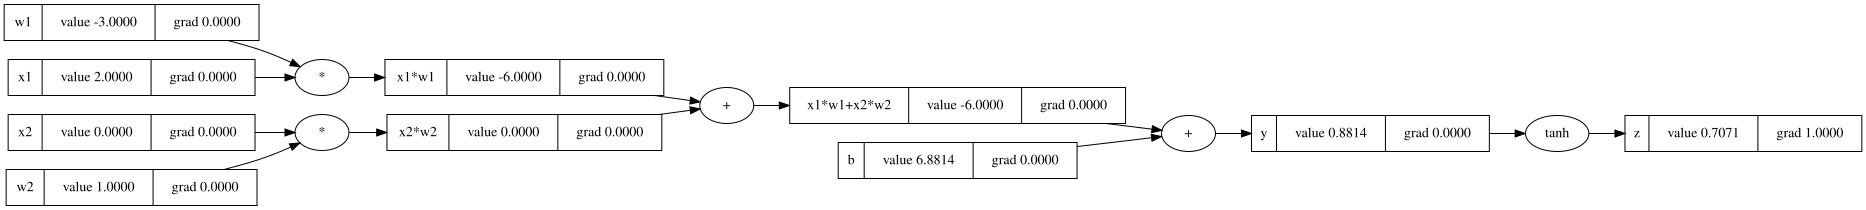

In [51]:
z.grad = 1.0
y.grad = 0.0
b.grad = 0.0
x1w1x2w2.grad = 0.0
x1w1.grad = 0.0
x2w2.grad = 0.0
x2.grad = 0.0
w2.grad = 0.0
x1.grad = 0.0
w1.grad = 0.0
pgv.draw_graph(z)

And we call the `acc_grads` function on the output $z$.

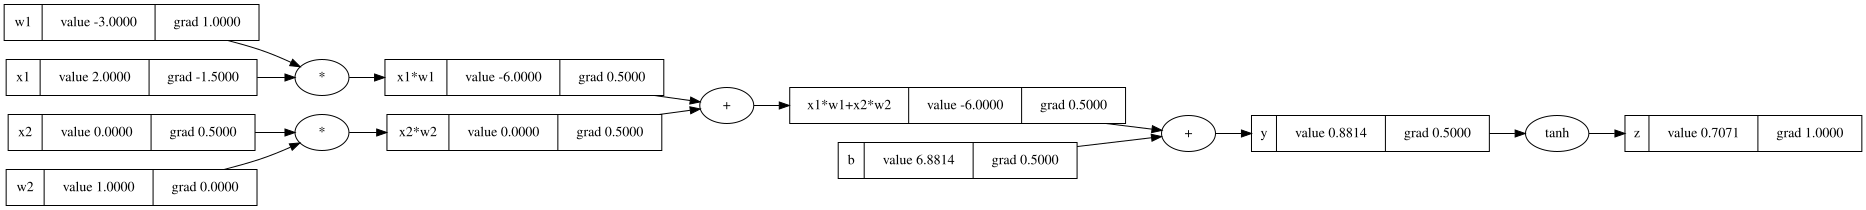

In [52]:
z.acc_grads()
pgv.draw_graph(z)

Using the `acc_grads` function on the output of the function graph, the gradients accumulate in the correct order.